In [1]:
!pip -q install pandas numpy python-dateutil networkx plotly pyvis igraph leidenalg matplotlib scipy scikit-learn tqdm
import os, sys, math, json, itertools, textwrap
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
from dateutil import parser as dtparser
import networkx as nx
import plotly.graph_objects as go
from pyvis.network import Network
import igraph as ig
import leidenalg as la
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm import tqdm

OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print("Outputs ->", OUT_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 103.0 MB/s eta 0:00:00
Outputs -> /content/outputs


In [2]:
import os, math, json
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import drive
USE_GOOGLE_DRIVE = True
EHRSHOT_DIR_IN_DRIVE = "/MyDrive/Sampledataset"
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DATA_DIR = Path("/content/drive") / EHRSHOT_DIR_IN_DRIVE.strip("/")
else:
    DATA_DIR = Path("/content/Sampledataset")
OUT_DIR  = Path("/content/outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)
def parse_date(s):
    if pd.isna(s): return pd.NaT
    return pd.to_datetime(s, errors="coerce", utc=True).tz_localize(None)
person   = pd.read_csv(DATA_DIR/"sampled_person.csv")
cond     = pd.read_csv(DATA_DIR/"sampled_condition_occurrence.csv")
concept  = pd.read_csv(DATA_DIR/"concept.csv")
person_cols = [c for c in ["person_id","birth_DATETIME","year_of_birth","month_of_birth","day_of_birth"] if c in person.columns]
person = person[person_cols].copy()
cond_cols = [c for c in [
    "condition_occurrence_id","person_id","condition_concept_id",
    "condition_start_DATE","condition_start_DATETIME"
] if c in cond.columns]
cond = cond[cond_cols].copy()
concept_cols = [c for c in ["concept_id","concept_name","domain_id","concept_class_id"] if c in concept.columns]
concept = concept[concept_cols].copy()
print(person.shape, cond.shape, concept.shape)


Mounted at /content/drive


/tmp/ipython-input-1722227009.py:28: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  cond     = pd.read_csv(DATA_DIR/"sampled_condition_occurrence.csv")
/tmp/ipython-input-1722227009.py:29: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  concept  = pd.read_csv(DATA_DIR/"concept.csv")  # only to show readable names already inside EHRSHOT


(2000, 5) (761822, 5) (8263683, 4)


In [3]:
import pandas as pd
def parse_datetime_series(s):
    dt = pd.to_datetime(s, errors="coerce", utc=True)
    return dt.dt.tz_localize(None)
def parse_date_series(s):
   return pd.to_datetime(s, errors="coerce")
evt = pd.Series(pd.NaT, index=cond.index, dtype="datetime64[ns]")
if "condition_start_DATETIME" in cond.columns and cond["condition_start_DATETIME"].notna().any():
    evt = parse_datetime_series(cond["condition_start_DATETIME"])
elif "condition_start_DATE" in cond.columns and cond["condition_start_DATE"].notna().any():
    evt = parse_date_series(cond["condition_start_DATE"])
else:
    raise ValueError(
        "No usable condition start date columns found. "
        "Expected one of: condition_start_DATETIME or condition_start_DATE."
    )
cond = cond.assign(event_date=evt)
print("event_date non-null rows:", cond["event_date"].notna().sum())
print(cond[["person_id","event_date"]].head())

event_date non-null rows: 761822
   person_id event_date
0  115969604 2014-11-03
1  115969604 2014-11-06
2  115969604 2014-08-09
3  115969604 2014-08-24
4  115968515 2015-09-02


In [4]:
cond[["person_id","event_date"]].head()
print(cond["event_date"].notna().sum())


761822


In [5]:
if "birth_DATETIME" in person.columns and person["birth_DATETIME"].notna().any():
    bd = pd.to_datetime(person["birth_DATETIME"], errors="coerce", utc=True).dt.tz_localize(None)
else:
    y = person.get("year_of_birth"); m = person.get("month_of_birth"); d = person.get("day_of_birth")
    m = m.fillna(6); d = d.fillna(15)
    bd = pd.to_datetime(dict(year=y, month=m, day=d), errors="coerce")
person = person.assign(birth_date=bd)
cond = cond.merge(person[["person_id","birth_date"]], on="person_id", how="left")
cond = cond.dropna(subset=["event_date","birth_date"])
age_years = (cond["event_date"] - cond["birth_date"]).dt.days / 365.25
cond["age_at_event"] = age_years
ELDERLY_MIN_AGE = 65
elder = cond[cond["age_at_event"] >= ELDERLY_MIN_AGE].copy()
elder = elder[elder["event_date"].between("1990-01-01","2025-12-31")]
print("Elderly condition rows:", len(elder))


Elderly condition rows: 294210


In [6]:
MAX_EVENTS_PER_PATIENT = 50
MAX_GAP_DAYS = 365*2
WITHIN_DAYS_FOR_COHERENCE = 180
elder = elder.sort_values(["person_id","event_date"])
elder["condition_concept_id"] = elder["condition_concept_id"].astype("Int64")
def collapse_runs(df):
    conds = df["condition_concept_id"].to_numpy()
    dates = df["event_date"].to_numpy()
    keep_idx = [0]
    for i in range(1, len(conds)):
        if conds[i] != conds[i-1]:
            keep_idx.append(i)
    out = df.iloc[keep_idx]
    return out.head(MAX_EVENTS_PER_PATIENT)
thin = elder.groupby("person_id", group_keys=False).apply(collapse_runs)
pairs = []
for pid, g in thin.groupby("person_id"):
    arr = g[["condition_concept_id","event_date","age_at_event"]].to_numpy()
    for i in range(len(arr)-1):
        a, tA, ageA = arr[i]
        b, tB, ageB = arr[i+1]
        if pd.isna(a) or pd.isna(b):
            continue
        lag = (pd.Timestamp(tB) - pd.Timestamp(tA)).days
        if lag < 0 or lag > MAX_GAP_DAYS:
            continue
        pairs.append((int(a), int(b), lag, float(ageA), float(ageB)))
pairs = pd.DataFrame(pairs, columns=["src","dst","lag_days","age_src","age_dst"])
print("Transitions kept:", len(pairs))


/tmp/ipython-input-974275017.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  thin = elder.groupby("person_id", group_keys=False).apply(collapse_runs)


Transitions kept: 31004


In [7]:
edge = pairs.groupby(["src","dst"]).agg(
    n=("lag_days","size"),
    med_lag=("lag_days","median"),
    p75=("lag_days", lambda x: np.percentile(x, 75)),
    p25=("lag_days", lambda x: np.percentile(x, 25)),
    coh=("lag_days", lambda x: np.mean(x <= WITHIN_DAYS_FOR_COHERENCE))
).reset_index()
edge["iqr"] = edge["p75"] - edge["p25"]
first_age = thin.groupby(["person_id","condition_concept_id"]).agg(
    first_age=("age_at_event","min"),
    first_time=("event_date","min")
).reset_index()

node_age = first_age.groupby("condition_concept_id").agg(
    med_age=("first_age","median"),
    n_patients=("first_age","size")
).reset_index().rename(columns={"condition_concept_id":"concept_id"})
TOP_CONCEPTS = 60
top_cids = node_age.sort_values("n_patients", ascending=False).head(TOP_CONCEPTS)["concept_id"].tolist()
edge = edge[edge["src"].isin(top_cids) & edge["dst"].isin(top_cids)]
MIN_EDGE_N      = 40
MIN_COHERENCE   = 0.35
edge_keep = edge[(edge["n"]>=MIN_EDGE_N) & (edge["coh"]>=MIN_COHERENCE)].copy()
print("Edges after thresholds:", len(edge_keep))


Edges after thresholds: 3


In [8]:
name_map = dict(zip(concept["concept_id"], concept["concept_name"]))
dom_map  = dict(zip(concept["concept_id"], concept.get("domain_id","").astype(str)))
node_age["name"] = node_age["concept_id"].map(name_map).fillna(node_age["concept_id"].astype(str))
node_age["domain"] = node_age["concept_id"].map(dom_map).fillna("")
edge_keep["src_name"] = edge_keep["src"].map(name_map).fillna(edge_keep["src"].astype(str))
edge_keep["dst_name"] = edge_keep["dst"].map(name_map).fillna(edge_keep["dst"].astype(str))


60 nodes, 3 edges


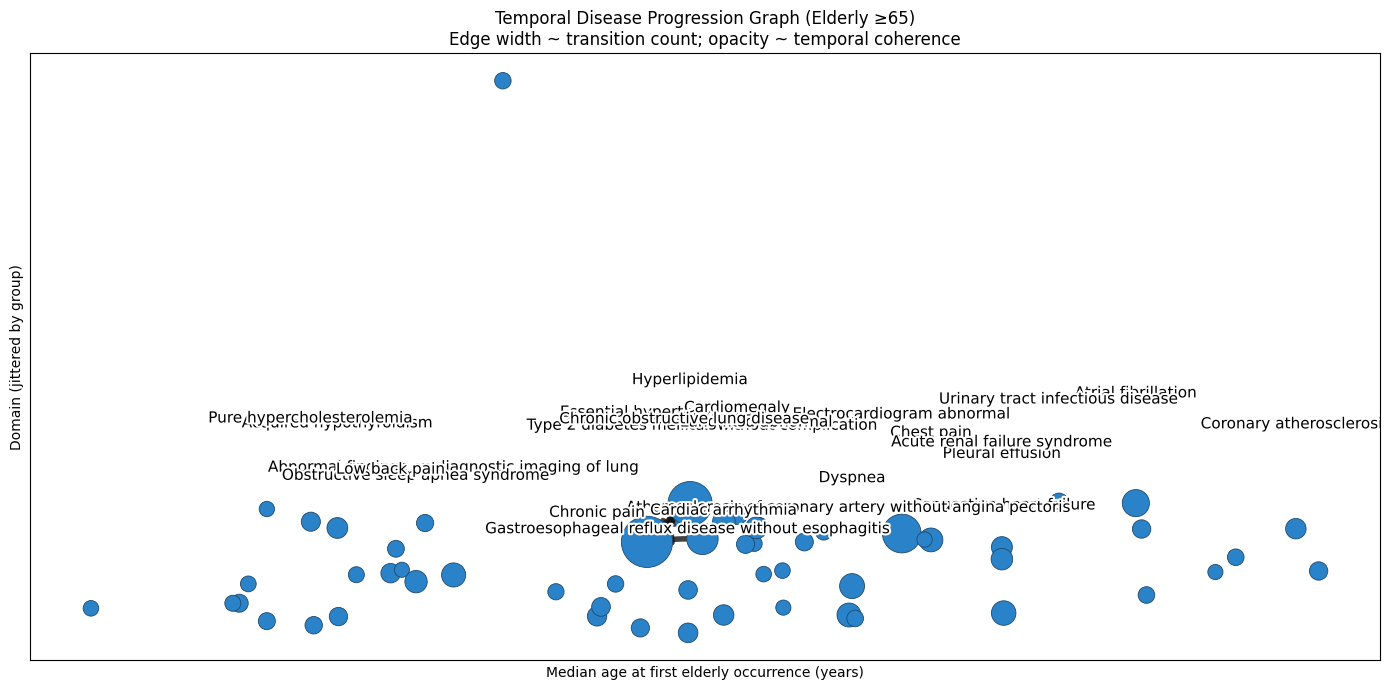

In [9]:
G = nx.DiGraph()
sub_nodes = node_age[node_age["concept_id"].isin(top_cids)].copy()
for _, r in sub_nodes.iterrows():
    G.add_node(int(r["concept_id"]),
               med_age=float(r["med_age"]),
               n_patients=int(r["n_patients"]),
               name=str(r["name"]))

for _, r in edge_keep.iterrows():
    G.add_edge(int(r["src"]), int(r["dst"]),
               n=int(r["n"]),
               med_lag=float(r["med_lag"]),
               coh=float(r["coh"]),
               iqr=float(r["iqr"]))
print(G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")
rng = np.random.default_rng(42)
pos = {}
dom_for = {n: dom_map.get(n, "") for n in G.nodes()}
uniq_dom = {d: i for i, d in enumerate(sorted(set(dom_for.values())))}

for n, data in G.nodes(data=True):
    x = data.get("med_age", 75.0)
    group = uniq_dom.get(dom_for.get(n, ""), 0)
    y = group + (rng.random() - 0.5) * 0.30
    pos[n] = np.array([x, y])
node_sizes_dict = {n: max(80, 3.5 * G.nodes[n]["n_patients"]) for n in G.nodes()}
node_sizes = [node_sizes_dict[n] for n in G.nodes()]
edge_w     = [max(0.8, math.log1p(d["n"])) for _, _, d in G.edges(data=True)]
edge_alpha = [0.2 + 0.6 * min(1.0, d["coh"]) for _, _, d in G.edges(data=True)]
plt.figure(figsize=(14, 7))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#2a83c9", edgecolors="#1f486a", linewidths=0.6)
for e, (u, v, d) in enumerate(G.edges(data=True)):
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        width=edge_w[e], alpha=edge_alpha[e],
        arrows=True, arrowsize=12, edge_color="#111", connectionstyle="arc3,rad=0.04"
    )
N_LABELS = 25
label_keep = [n for n, _ in sorted(
    ((n, G.nodes[n]["n_patients"]) for n in G.nodes()),
    key=lambda x: x[1], reverse=True
)[:N_LABELS]]
labels = {n: (G.nodes[n]["name"] if G.nodes[n]["name"] else str(n)) for n in label_keep}
def dy(n):
    return 0.18 + 0.0025 * math.sqrt(node_sizes_dict.get(n, 80))

label_pos = {n: (pos[n][0], pos[n][1] + dy(n)) for n in label_keep}
import matplotlib.patheffects as pe
text_objs = nx.draw_networkx_labels(
    G, label_pos, labels=labels,
    font_size=11, font_color="black",
    horizontalalignment="center", verticalalignment="bottom"
)
for txt in text_objs.values():
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])
plt.xlabel("Median age at first elderly occurrence (years)")
plt.ylabel("Domain (jittered by group)")
plt.title(
    "Temporal Disease Progression Graph (Elderly ≥65)\n"
    "Edge width ~ transition count; opacity ~ temporal coherence"
)
plt.tight_layout()
plt.show()


In [10]:
!pip -q install plotly
import plotly.graph_objects as go
edge_keep["strength"] = edge_keep["n"] * edge_keep["coh"]
topE = edge_keep.sort_values("strength", ascending=False).head(40).copy()
nodes_in = sorted(set(topE["src_name"]).union(set(topE["dst_name"])))
idx = {name:i for i,name in enumerate(nodes_in)}

sankey = go.Figure(data=[go.Sankey(
    node=dict(label=nodes_in, pad=10, thickness=12),
    link=dict(
        source=topE["src_name"].map(idx),
        target=topE["dst_name"].map(idx),
        value=topE["n"],
        customdata=np.stack([topE["med_lag"].round(1), (topE["coh"]*100).round(1)], axis=1),
        hovertemplate=" %{source.label} → %{target.label}<br>Transitions: %{value}<br>Median days: %{customdata[0]}<br>Coherence (≤180d): %{customdata[1]}%<extra></extra>"
    )
)])
sankey.update_layout(title_text="Top Elderly Disease Progression Flows (Sankey)", font_size=11, height=600)
sankey.write_html(str(OUT_DIR/"elderly_progression_sankey.html"))
sankey.show()
print("Saved:", OUT_DIR/"elderly_progression_sankey.html")


Saved: /content/outputs/elderly_progression_sankey.html


In [11]:
out_deg = dict(G.out_degree())
in_deg  = dict(G.in_degree())
summ = edge_keep.assign(strength=lambda d: d["n"]*d["coh"])
top_edges = summ.sort_values("strength", ascending=False).head(12)
print("\n=== Top temporal transitions in elderly (count × coherence) ===")
for _, r in top_edges.iterrows():
    print(f"- {r['src_name']} → {r['dst_name']}: "
          f"{int(r['n'])} transitions; median {int(r['med_lag'])} days; "
          f"IQR {int(r['iqr'])}d; coherence≤{WITHIN_DAYS_FOR_COHERENCE}d = {r['coh']:.2f}")
absorbing = [n for n in G.nodes() if out_deg.get(n,0)==0 and in_deg.get(n,0)>0]
if absorbing:
    print("\n=== Possible late/terminal states (low out-degree) ===")
    for n in absorbing[:10]:
        print(f"- {G.nodes[n]['name']} (median age {G.nodes[n]['med_age']:.1f}y, elderly patients {G.nodes[n]['n_patients']})")
sources = [n for n in G.nodes() if in_deg.get(n,0)==0 and out_deg.get(n,0)>0]
if sources:
    print("\n=== Common initial elderly conditions (high out-degree, zero in-degree) ===")
    for n in sources[:10]:
        print(f"- {G.nodes[n]['name']} → {out_deg[n]} onward transitions "
              f"(median age {G.nodes[n]['med_age']:.1f}y, patients {G.nodes[n]['n_patients']})")



=== Top temporal transitions in elderly (count × coherence) ===
- Hyperlipidemia → Essential hypertension: 117 transitions; median 0 days; IQR 0d; coherence≤180d = 0.97
- Essential hypertension → Hyperlipidemia: 77 transitions; median 0 days; IQR 0d; coherence≤180d = 0.96
- Type 2 diabetes mellitus without complication → Essential hypertension: 53 transitions; median 0 days; IQR 0d; coherence≤180d = 1.00

=== Common initial elderly conditions (high out-degree, zero in-degree) ===
- Type 2 diabetes mellitus without complication → 1 onward transitions (median age 71.0y, patients 146)


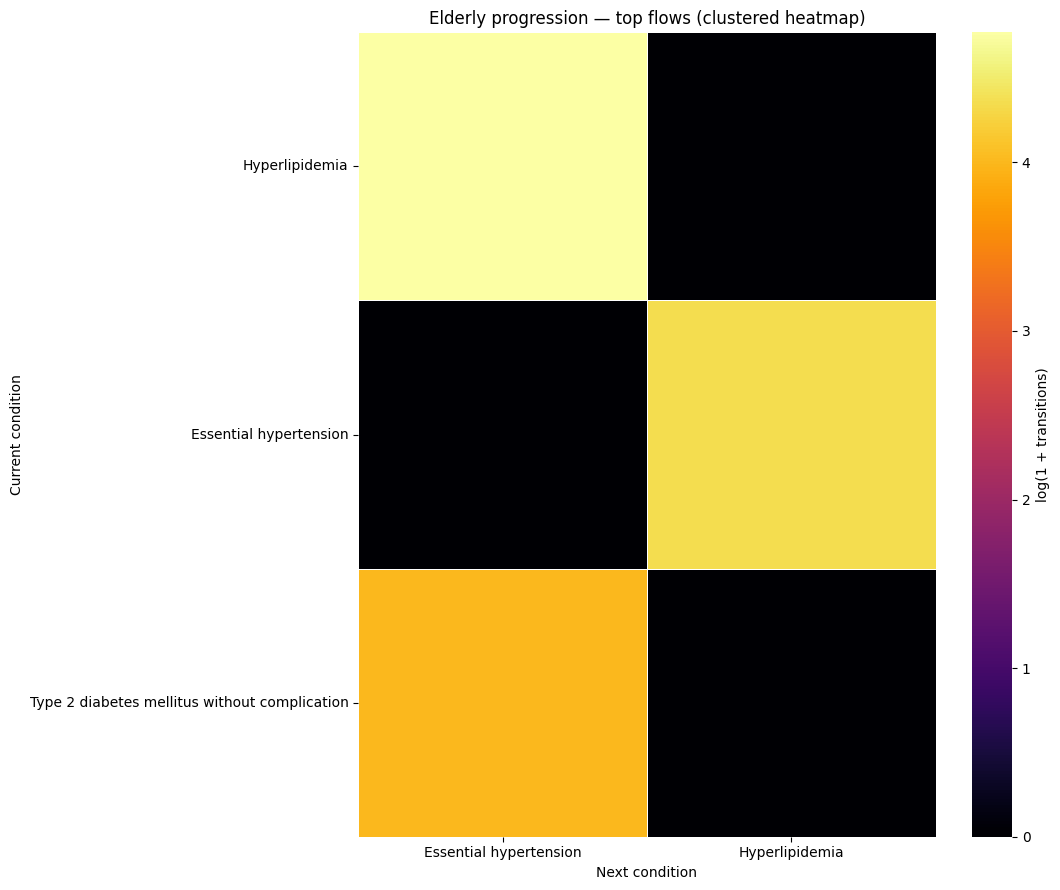

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
K = 35
topE = (edge_keep.assign(strength=lambda d: d["n"]*d["coh"])
        .sort_values("strength", ascending=False).head(K))
pivot = (topE
    .groupby(["src_name","dst_name"])["n"]
    .sum().unstack(fill_value=0))
row_order = pivot.sum(axis=1).sort_values(ascending=False).index
col_order = pivot.sum(axis=0).sort_values(ascending=False).index
pivot = pivot.loc[row_order, col_order]

plt.figure(figsize=(11,9))
ax = sns.heatmap(np.log1p(pivot), cmap="inferno", linewidth=0.5, linecolor="white",
                 cbar_kws={"label":"log(1 + transitions)"})
ax.set_xlabel("Next condition")
ax.set_ylabel("Current condition")
plt.title("Elderly progression — top flows (clustered heatmap)")
plt.tight_layout()
plt.show()


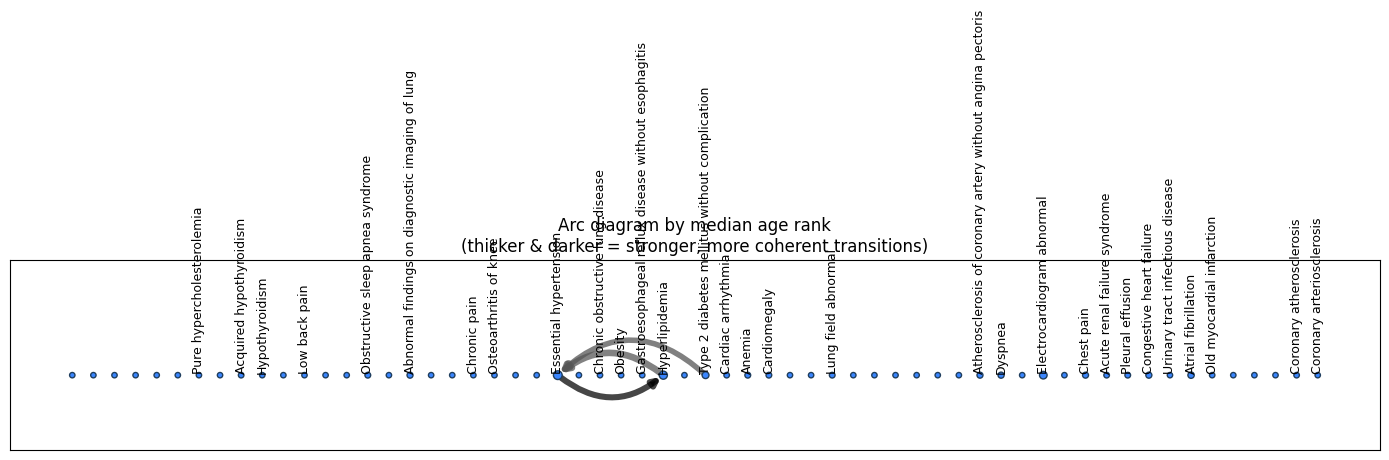

In [14]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
dfn = (node_age.loc[node_age["concept_id"].isin(G.nodes())]
       .drop_duplicates("concept_id")
       .set_index("concept_id"))

order = dfn["med_age"].sort_values().index.tolist()
xpos = {n:i for i,n in enumerate(order)}
name = dfn["name"].to_dict()
n_pat = dfn["n_patients"].to_dict()
label_keep = {n for n,_ in sorted(n_pat.items(), key=lambda x:x[1], reverse=True)[:30]}
plt.figure(figsize=(14,4))
xs = [xpos[n] for n in order]
sizes = [max(15, np.sqrt(n_pat.get(n,1))*2) for n in order]
plt.scatter(xs, np.zeros_like(xs), s=sizes, color="#3a86ff", edgecolor="#1f3e5e", zorder=3)
for n in order:
    if n in label_keep:
        plt.text(xpos[n], 0.08, name.get(n,str(n)), rotation=90, va="bottom", ha="center", fontsize=9)
for u,v,d in G.edges(data=True):
    x1, x2 = xpos[u], xpos[v]
    if x1 == x2:
        continue
    rad = 0.25 + 0.03*abs(x2-x1)
    lw  = max(0.5, np.log1p(d.get("n",1)))
    alpha = 0.15 + 0.6*min(1.0, d.get("coh",0))
    color = "#000000" if x2>x1 else "#555555"
    arrow = FancyArrowPatch((x1,0),(x2,0), connectionstyle=f"arc3,rad={rad}",
                            arrowstyle="-|>", mutation_scale=10, lw=lw, color=color, alpha=alpha)
    plt.gca().add_patch(arrow)
plt.xticks([])
plt.yticks([])
plt.title("Arc diagram by median age rank\n(thicker & darker = stronger, more coherent transitions)")
plt.tight_layout()
plt.show()


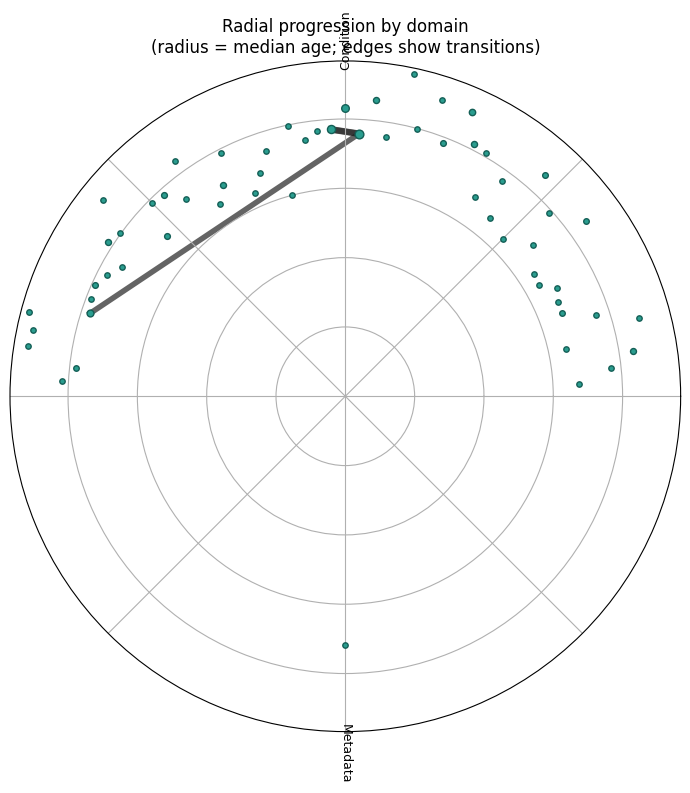

In [15]:
import math, matplotlib.pyplot as plt
from collections import defaultdict
domains = sorted({dom_map.get(n,"Other") for n in G.nodes()})
by_dom = defaultdict(list)
for n in G.nodes():
    by_dom[dom_map.get(n,"Other")].append(n)
wedges = np.linspace(0, 2*math.pi, len(domains)+1)
theta = {}
for i,d in enumerate(domains):
    nodes = by_dom[d]
    if not nodes:
        continue
    angs = np.linspace(wedges[i], wedges[i+1], len(nodes)+2)[1:-1]
    for n,a in zip(nodes, angs):
        theta[n] = a
med = {n:G.nodes[n].get("med_age",75.0) for n in G.nodes()}
mmin, mmax = min(med.values()), max(med.values())
rad  = {n: 0.6 + 0.35*(med[n]-mmin)/(mmax-mmin+1e-9) for n in G.nodes()}
plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection="polar")
for n in G.nodes():
    ax.scatter(theta[n], rad[n], s=max(15, math.sqrt(G.nodes[n].get("n_patients",1))*2),
               color="#2a9d8f", edgecolors="#145f56", zorder=3)
for u,v,d in G.edges(data=True):
    a1,a2 = theta[u], theta[v]
    r1,r2 = rad[u], rad[v]
    lw = max(0.6, math.log1p(d.get("n",1)))
    alpha = 0.1 + 0.6*min(1.0, d.get("coh",0))
    ax.plot([a1,a2],[r1,r2], color="#222", lw=lw, alpha=alpha, zorder=1)
for i,d in enumerate(domains):
    ang = (wedges[i]+wedges[i+1])/2
    ax.text(ang, 1.03, d, rotation=np.degrees(ang), ha="center", va="center", fontsize=9)

ax.set_yticklabels([]); ax.set_xticklabels([])
plt.title("Radial progression by domain\n(radius = median age; edges show transitions)")
plt.tight_layout()
plt.show()


In [16]:
!pip -q install plotly
import plotly.graph_objects as go
K = 50
E = (edge_keep.assign(strength=lambda d: d["n"]*d["coh"])
     .sort_values("strength", ascending=False).head(K).copy())
names = sorted(set(E["src_name"]).union(E["dst_name"]))
id_map = {name:i for i,name in enumerate(names)}
fig = go.Figure(go.Sankey(
    arrangement="snap",
    node = dict(
        pad=12, thickness=16,
        label=names
    ),
    link = dict(
        source = E["src_name"].map(id_map),
        target = E["dst_name"].map(id_map),
        value  = E["n"],
        color  = ["rgba(30,30,30,{:.2f})".format(0.25+0.6*min(1.0,c)) for c in E["coh"]],
        hovertemplate=("From %{source.label} → %{target.label}<br>"
                       "Transitions: %{value}<br>"
                       "Coherence (same-patient order): %{customdata[0]:.2f}<br>"
                       "Median lag (days): %{customdata[1]:.0f}<extra></extra>"),
        customdata = np.c_[E["coh"], E["med_lag"]]
    )
))
fig.update_layout(title="Elderly disease flows — top coherent transitions", font_size=12)
fig.write_html("/content/outputs/elderly_sankey.html"); fig.show()
print("Saved to /content/outputs/elderly_sankey.html")


Saved to /content/outputs/elderly_sankey.html


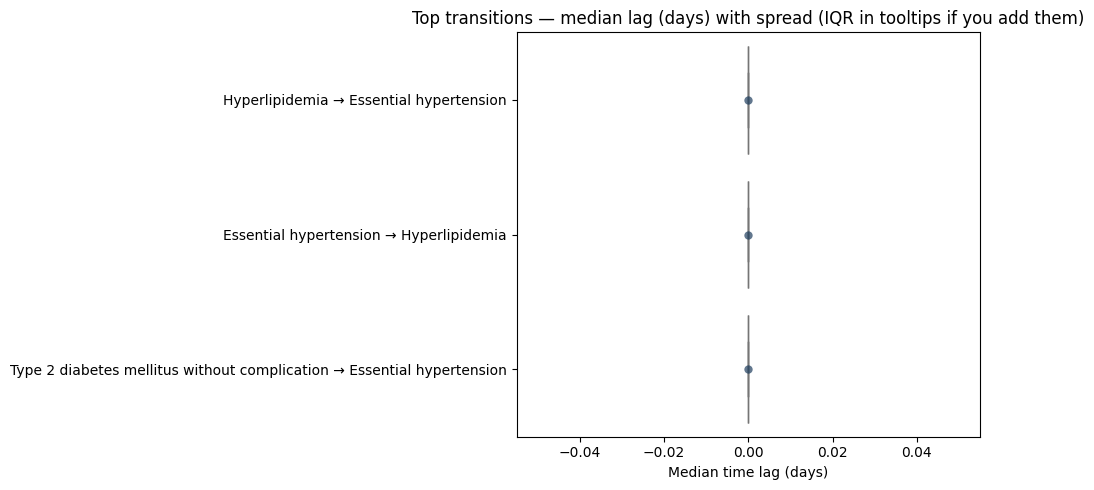

In [17]:
import seaborn as sns, matplotlib.pyplot as plt
E10 = edge_keep.sort_values("n", ascending=False).head(10).copy()
E10["pair"] = E10["src_name"] + " → " + E10["dst_name"]
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=E10, y="pair", x="med_lag", orient="h", color="#86b5ff")
sns.stripplot(data=E10, y="pair", x="med_lag", orient="h", color="#1f3e5e", alpha=0.7, size=6)
ax.set_xlabel("Median time lag (days)")
ax.set_ylabel("")
plt.title("Top transitions — median lag (days) with spread (IQR in tooltips if you add them)")
plt.tight_layout()
plt.show()


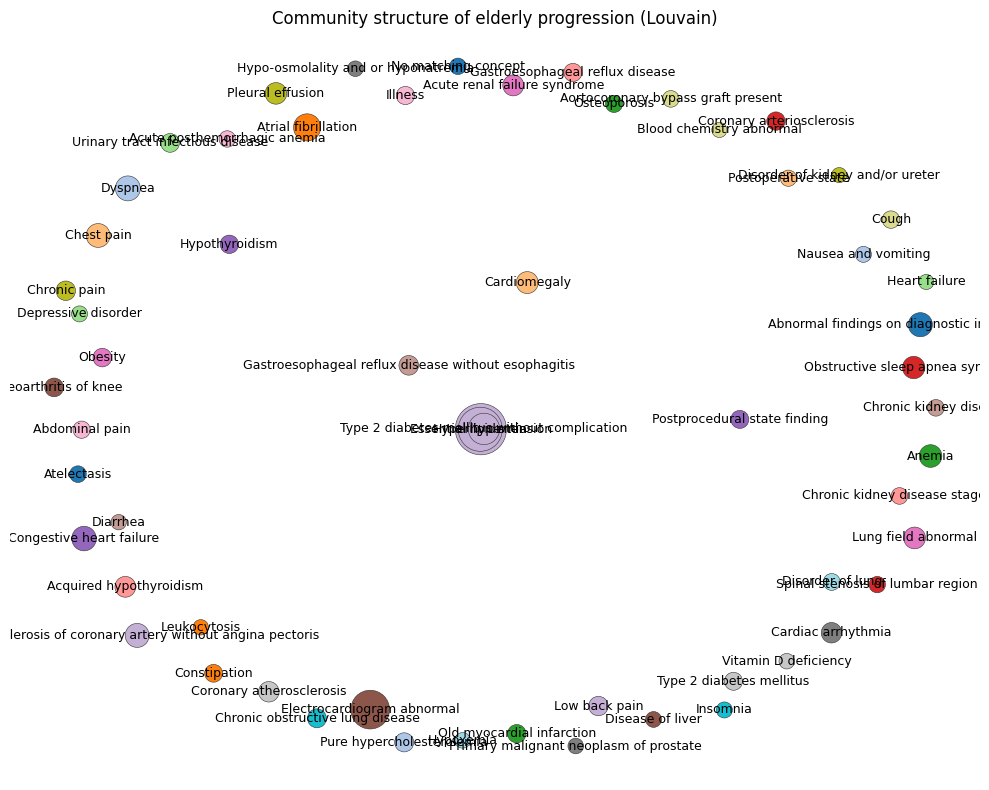

In [18]:
!pip -q install python-louvain
import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np, math
H = nx.Graph()
for n,d in G.nodes(data=True):
    H.add_node(n, **d)
for u,v,d in G.edges(data=True):
    H.add_edge(u,v, weight=float(d.get("n",1))*float(d.get("coh",0.5)))
part = community_louvain.best_partition(H, weight="weight", random_state=42)
colors = {c:plt.cm.tab20(c%20) for c in set(part.values())}
pos = nx.spring_layout(H, weight="weight", seed=42, k=0.35/np.sqrt(max(1,len(H))))
sizes = [max(80, 3.5*G.nodes[n].get("n_patients",1)) for n in H.nodes()]
plt.figure(figsize=(10,8))
nx.draw_networkx_edges(H, pos, alpha=0.25, width=[max(0.5, math.log1p(H[u][v]["weight"])) for u,v in H.edges()])
nx.draw_networkx_nodes(H, pos,
    node_size=sizes,
    node_color=[colors[part[n]] for n in H.nodes()],
    edgecolors="#333", linewidths=0.4)
hubs = []
for c in set(part.values()):
    members = [n for n in H.nodes() if part[n]==c]
    top = sorted(members, key=lambda n: H.degree(n, weight="weight"), reverse=True)[:6]
    hubs.extend(top)
lbl = {n: G.nodes[n]["name"] for n in hubs}
nx.draw_networkx_labels(H, pos, labels=lbl, font_size=9)

plt.title("Community structure of elderly progression (Louvain)")
plt.axis("off"); plt.tight_layout(); plt.show()


([Text(0.0672883064516129, 0.6374056066511261, 'Chest pain'),
  Text(0.1978326612903226, 0.8813579020156878, 'Urinary tract infectious disease'),
  Text(0.15675403225806453, 0.017586580086580067, 'Acquired hypothyroidism'),
  Text(0.09929435483870966, 0.581836840077733, 'Hypothyroidism'),
  Text(0.6442141197897103, 0.017586580086580067, 'Low back pain'),
  Text(0.20073084677419353, 0.9824134199134199, 'Acute renal failure syndrome'),
  Text(0.18283770161290322, 0.9824134199134199, 'Pleural effusion'),
  Text(0.1688508064516129, 0.017586580086580067, 'Chronic obstructive lung disease'),
  Text(0.0551915322580645, 0.7752912722433389, 'Dyspnea'),
  Text(0.10093245967741934, 0.9349260064291115, 'Atrial fibrillation'),
  Text(0.1381048387096774, 0.5070313991449521, 'Cardiomegaly'),
  Text(0.6328125, 0.017586580086580067, 'Old myocardial infarction'),
  Text(0.7175698242479955, 0.9715987797170104, 'Coronary arteriosclerosis'),
  Text(0.15234374999999997, 0.017586580086580067, 'Congestive hea

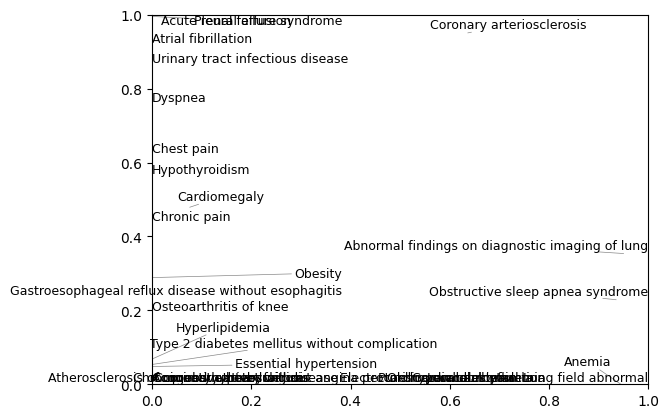

In [19]:
!pip -q install adjustText
from adjustText import adjust_text
texts = []
for n,(x,y) in pos.items():
    if n in label_keep:
        texts.append(plt.text(x, y+0.12, G.nodes[n]["name"], ha="center", fontsize=9))
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="#888", lw=0.5))
